In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline


In [2]:
DATA_PATH = Path('../data/processed/nykaa_campaign_features.csv')

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 55555 rows x 53 columns


,Campaign_ID,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Spend,CTR,Conversion_Rate,CPC,CPA,ROAS,CPL,Lead_Rate,Lead_to_Conversion_Rate,Overall_Funnel_Efficiency,Impressions_per_Day,Clicks_per_Day,Leads_per_Day,Conversions_per_Day,Spend_per_Day,Year,Month,Quarter,Day_of_Week,Is_Weekend,Channel_Count,Is_Multichannel,Channel_Email,Channel_Facebook,Channel_Google,Channel_Instagram,Channel_WhatsApp,Channel_YouTube,Campaign_Type_Influencer,Campaign_Type_Paid Ads,Campaign_Type_SEO,Campaign_Type_Social Media,Target_Audience_Premium Shoppers,Target_Audience_Tier 2 City Customers,Target_Audience_Working Women,Target_Audience_Youth,Language_English,Language_Hindi,Language_Tamil,Customer_Segment_Premium Shoppers,Customer_Segment_Tier 2 City Customers,Customer_Segment_Working Women,Customer_Segment_Youth
0,NY-CMP-1000,21,57804,6156,3616,2355,1867515,111.03,6.14,20.98,261475.65,10.649782,38.255361,42.474927,111.03,7.142214,72.310744,58.739441,65.127212,4.074113,2752.571429,293.142857,172.190476,112.142857,12451.221429,2025,4,2,1,0,2,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,NY-CMP-1001,18,91801,3321,1971,1357,1046247,180.83,3.26,7.24,245386.31,3.617608,40.861186,73.889283,180.83,4.263673,124.498382,59.349593,68.848300,1.478197,5100.055556,184.500000,109.500000,75.388889,13632.572778,2025,4,2,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
2,NY-CMP-1002,23,15536,2182,952,755,197055,90.60,1.88,25.03,68403.00,14.044799,34.601283,31.348763,90.60,2.880795,71.851891,43.629698,79.306723,4.859681,675.478261,94.869565,41.391304,32.826087,2974.043478,2025,1,1,1,0,3,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,NY-CMP-1003,18,88114,8413,2231,947,376906,249.07,0.60,13.15,235869.29,9.547858,11.256389,28.036288,249.07,1.597944,105.723572,26.518483,42.447333,1.074744,4895.222222,467.388889,123.944444,52.611111,13103.849444,2025,6,2,2,0,3,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,NY-CMP-1004,10,96871,3743,2060,1258,518296,228.60,0.80,7.29,287578.80,3.863901,33.609404,76.831098,228.60,1.802275,139.601359,55.036067,61.067961,1.298634,9687.100000,374.300000,206.000000,125.800000,28757.880000,2024,12,4,6,1,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


In [3]:
ID_COLUMNS = ['Campaign_ID']

# Columns that are an exact mathematical function of the target column.
# These must never be used to predict that target.
LEAKAGE_RULES = {
    'Revenue': {
        'exclude': ['Revenue', 'ROAS', 'ROI'],
        'caution': [],
    },
    'Conversions': {
        'exclude': [
            'Conversions', 'Spend', 'Spend_per_Day', 'CPC', 'CPA', 'CPL', 'ROAS',
            'Conversion_Rate', 'Lead_to_Conversion_Rate', 'Overall_Funnel_Efficiency',
            'Conversions_per_Day',
        ],
        'caution': ['Revenue', 'ROI'],  # separately-generated outcome column, not formula-derived
    },
    'ROAS': {
        'exclude': ['ROAS', 'Revenue', 'ROI', 'Spend', 'Spend_per_Day', 'CPC', 'CPA', 'CPL'],
        'caution': ['Conversions', 'Conversion_Rate'],
    },
    'Clicks': {
        'exclude': [
            'Clicks', 'CTR', 'Clicks_per_Day', 'Conversion_Rate', 'CPC', 'Lead_Rate',
        ],
        'caution': ['Leads', 'Leads_per_Day', 'Conversions', 'Spend'],
    },
}

print("Leakage rules defined for targets:", list(LEAKAGE_RULES.keys()))


Leakage rules defined for targets: ['Revenue', 'Conversions', 'ROAS', 'Clicks']


In [4]:
def build_feature_target(data: pd.DataFrame, target: str, include_caution: bool = False):
    """Split `data` into (X, y) for the given target, applying the leakage rules above.

    Parameters
    ----------
    include_caution : if False (default), columns listed under 'caution' for this target
        are also dropped — the conservative choice. Set True to keep them as predictors.
    """
    if target not in data.columns:
        raise ValueError(f"Target column '{target}' not found in dataset.")

    rules = LEAKAGE_RULES.get(target, {'exclude': [target], 'caution': []})
    drop_cols = set(ID_COLUMNS) | set(rules['exclude'])
    if not include_caution:
        drop_cols |= set(rules['caution'])
    drop_cols &= set(data.columns)  # only drop what actually exists

    y = data[target]
    X = data.drop(columns=list(drop_cols))
    # Target itself must never remain in X even if it wasn't explicitly listed
    if target in X.columns:
        X = X.drop(columns=[target])

    return X, y, sorted(drop_cols)


In [5]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = [c for c in X.columns if X[c].nunique() > 2]
    passthrough_cols = [c for c in X.columns if c not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('scale', StandardScaler(), numeric_cols),
            ('passthrough', 'passthrough', passthrough_cols),
        ]
    )
    return preprocessor, numeric_cols, passthrough_cols


In [6]:
PRIMARY_TARGET = 'Revenue'

X, y, dropped_cols = build_feature_target(df, PRIMARY_TARGET)
print(f"Target: {PRIMARY_TARGET}")
print(f"Dropped for leakage/ID: {dropped_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Target: Revenue
Dropped for leakage/ID: ['Campaign_ID', 'ROAS', 'ROI', 'Revenue']
X shape: (55555, 49), y shape: (55555,)

Train: (44444, 49), Test: (11111, 49)


## Models & Hyperparameter 



In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

MODEL_SPECS = {
    'Linear Regression': {
        'estimator': LinearRegression(),
        'param_distributions': None,  # nothing meaningful to tune
    },
    'Random Forest': {
    'estimator': RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'param_distributions': {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [8, 12, 16],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 0.6, 1.0],
    },
},
    'XGBoost': {
        'estimator': XGBRegressor(
            random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror'
        ),
        'param_distributions': {
            'model__n_estimators': [200, 300, 400],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
        },
    },
}

print("Models configured:", list(MODEL_SPECS.keys()))


Models configured: ['Linear Regression', 'Random Forest', 'XGBoost']


In [9]:
def run_regression_experiment(
    X_train, y_train, model_name: str, cv=cv, n_iter: int = 5
):
    spec = MODEL_SPECS[model_name]
    preprocessor, _, _ = build_preprocessor(X_train)

    # Create a fresh estimator for every experiment
    if model_name == 'Linear Regression':
        estimator = LinearRegression()
    else:
        estimator = spec['estimator']

    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

    rmse_scorer = make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False,
    )

    if spec['param_distributions'] is None:

        cv_results = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=rmse_scorer,
            n_jobs=-1
        )

        pipeline.fit(X_train, y_train)

        best_params = {}

        # Actual RMSE for each of the 5 folds
        cv_rmse = -cv_results['test_score']

        cv_rmse_mean = cv_rmse.mean()
        cv_rmse_std = cv_rmse.std()

    else:

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=spec['param_distributions'],
            n_iter=n_iter,
            cv=cv,
            scoring=rmse_scorer,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=2,
            refit=True,
        )

        search.fit(X_train, y_train)

        pipeline = search.best_estimator_
        best_params = search.best_params_

        best_idx = search.best_index_

        # Actual mean and standard deviation across CV folds
        cv_rmse_mean = -search.cv_results_['mean_test_score'][best_idx]
        cv_rmse_std = search.cv_results_['std_test_score'][best_idx]

    return {
        'model_name': model_name,
        'pipeline': pipeline,
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'best_params': best_params,
    }

In [10]:
def evaluate_regression(pipeline, X_test, y_test) -> dict:
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


In [11]:
import time

results = {}

for model_name in MODEL_SPECS:

    print(f"\nTraining: {model_name} ...")

    # Start timer for this model
    model_start = time.perf_counter()

    # Training + Cross Validation
    start = time.perf_counter()
    run_result = run_regression_experiment(
        X_train, y_train, model_name
    )
    training_time = time.perf_counter() - start

    print(f"  ⏱ Training + CV time: {training_time:.2f} seconds")

    # Test evaluation
    start = time.perf_counter()
    test_metrics = evaluate_regression(
        run_result['pipeline'],
        X_test,
        y_test
    )
    evaluation_time = time.perf_counter() - start

    print(f"  ⏱ Evaluation time: {evaluation_time:.2f} seconds")

    # Save results
    results[model_name] = {
        **run_result,
        **test_metrics,
        "training_time": training_time,
        "evaluation_time": evaluation_time
    }

    total_time = time.perf_counter() - model_start

    print(
        f"  CV RMSE: {run_result['cv_rmse_mean']:,.2f} "
        f"(+/- {run_result['cv_rmse_std']:,.2f})"
    )
    print(
        f"  Test RMSE: {test_metrics['RMSE']:,.2f} "
        f"Test R2: {test_metrics['R2']:.4f}"
    )
    print(f"  ⏱ TOTAL TIME: {total_time:.2f} seconds")


print("\nAll models trained.")


Training: Linear Regression ...
  ⏱ Training + CV time: 4.04 seconds
  ⏱ Evaluation time: 0.01 seconds
  CV RMSE: 234,320.45 (+/- 1,927.02)
  Test RMSE: 231,673.77 Test R2: 0.7779
  ⏱ TOTAL TIME: 4.06 seconds

Training: Random Forest ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   2.1s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   2.9s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   2.7s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   2.9s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   2.7s
[CV] END model__max_depth=8, model__max_features=sqrt, model__min_

In [12]:
comparison_df = pd.DataFrame({
    name: {
        'CV_RMSE_mean': r['cv_rmse_mean'],
        'CV_RMSE_std': r['cv_rmse_std'],
        'Test_MAE': r['MAE'],
        'Test_MSE': r['MSE'],
        'Test_RMSE': r['RMSE'],
        'Test_R2': r['R2'],
    }
    for name, r in results.items()
}).T.sort_values('Test_RMSE')

comparison_df.style.format("{:.2f}")

,CV_RMSE_mean,CV_RMSE_std,Test_MAE,Test_MSE,Test_RMSE,Test_R2
Linear Regression,234320.45,1927.02,155284.46,53672737949.53,231673.77,0.78
Random Forest,236009.27,1396.81,155391.99,54275331984.94,232970.67,0.78
XGBoost,236029.12,1411.17,155547.95,54311022592.00,233047.25,0.78


In [13]:
best_model_name = comparison_df['Test_RMSE'].idxmin()
best_pipeline = results[best_model_name]['pipeline']

print("Best model:", best_model_name)

Best model: Linear Regression


In [14]:
y_pred = best_pipeline.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual_Revenue': y_test.values,
    'Predicted_Revenue': y_pred
})

prediction_df['Error'] = (
    prediction_df['Actual_Revenue'] -
    prediction_df['Predicted_Revenue']
)

prediction_df['Absolute_Error'] = prediction_df['Error'].abs()

prediction_df.head(10).style.format({
    'Actual_Revenue': '{:,.2f}',
    'Predicted_Revenue': '{:,.2f}',
    'Error': '{:,.2f}',
    'Absolute_Error': '{:,.2f}'
})

,Actual_Revenue,Predicted_Revenue,Error,Absolute_Error
0,"13,005.00","26,697.28","-13,692.28","13,692.28"
1,"1,228,654.00","1,049,689.89","178,964.11","178,964.11"
2,"65,412.00","93,851.33","-28,439.33","28,439.33"
3,"958,489.00","757,874.80","200,614.20","200,614.20"
4,"110,950.00","166,411.30","-55,461.30","55,461.30"
5,"734,296.00","529,281.38","205,014.62","205,014.62"
6,"169,320.00","421,212.74","-251,892.74","251,892.74"
7,"129,970.00","122,798.20","7,171.80","7,171.80"
8,"457,098.00","1,065,267.43","-608,169.43","608,169.43"
9,"548,120.00","393,724.88","154,395.12","154,395.12"


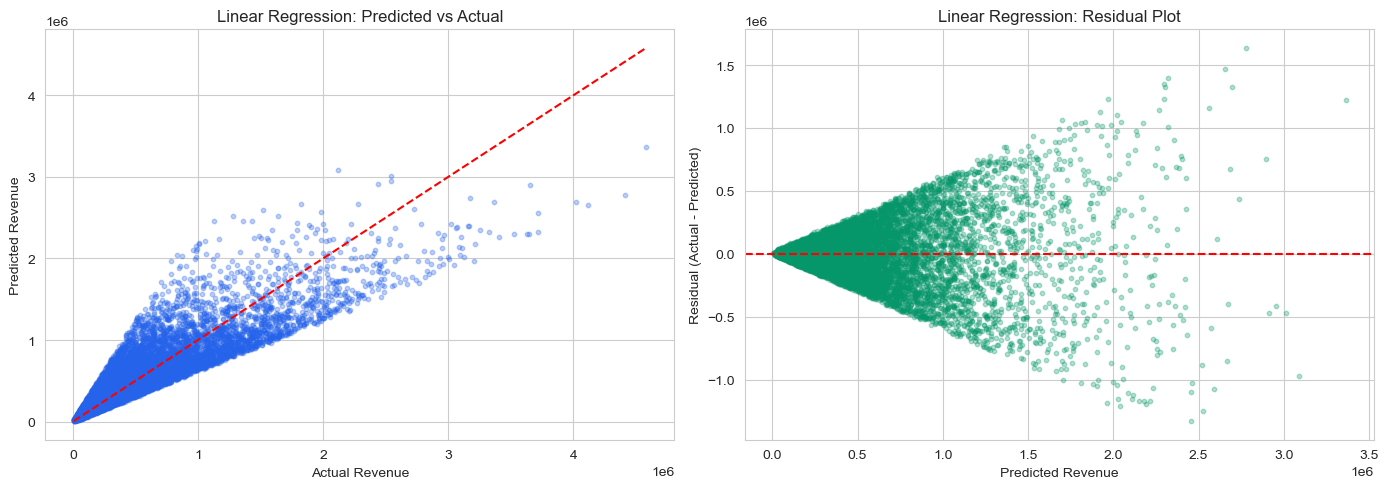

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.3,
    s=10,
    color='#2563eb'
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel(f'Actual {PRIMARY_TARGET}')
axes[0].set_ylabel(f'Predicted {PRIMARY_TARGET}')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')

# Residual plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.3,
    s=10,
    color='#059669'
)

axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel(f'Predicted {PRIMARY_TARGET}')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'{best_model_name}: Residual Plot')

plt.tight_layout()
plt.show()

The Linear Regression model predicts lower and medium revenue values relatively better, but it tends to underestimate campaigns with very high revenue.

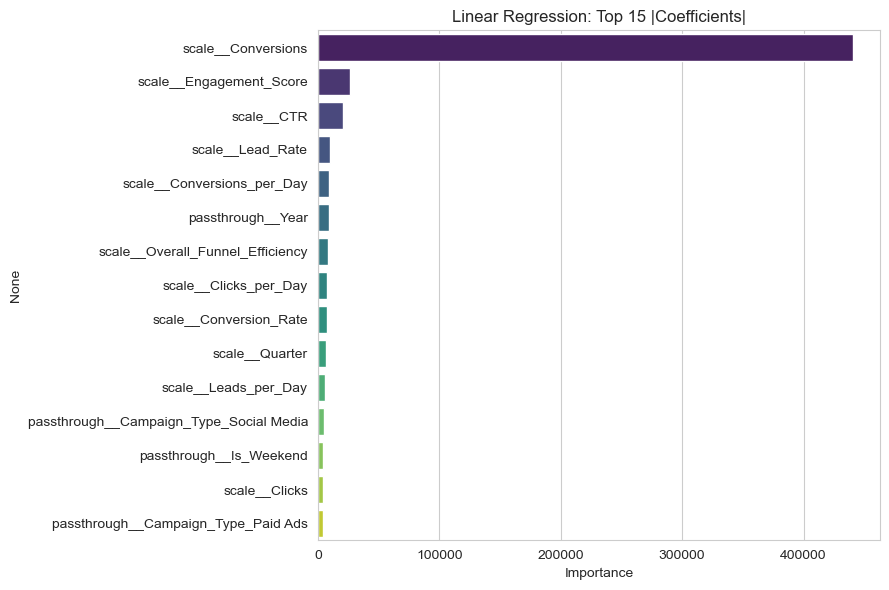

In [17]:
# Feature importance (tree models) or coefficients (linear model) — whichever applies
model_step = best_pipeline.named_steps['model']
preprocess_step = best_pipeline.named_steps['preprocess']
feature_names = preprocess_step.get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)
    title = f'{best_model_name}: Top 15 Feature Importances'
elif hasattr(model_step, 'coef_'):
    importances = pd.Series(np.abs(model_step.coef_), index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)
    title = f'{best_model_name}: Top 15 |Coefficients|'
else:
    importances = None

if importances is not None:
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


In [18]:
OTHER_TARGETS = ['Conversions', 'ROAS', 'Clicks']

all_results_rows = []

# Record the primary target's results first, for a complete leaderboard
for model_name, r in results.items():
    all_results_rows.append({
        'Target': PRIMARY_TARGET, 'Model': model_name,
        'Test_MAE': r['MAE'], 'Test_MSE': r['MSE'], 'Test_RMSE': r['RMSE'], 'Test_R2': r['R2'],
    })

for target in OTHER_TARGETS:
    print(f"\n=== Target: {target} ===")
    X_t, y_t, dropped_t = build_feature_target(df, target)
    print(f"Dropped for leakage/ID: {dropped_t}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, random_state=RANDOM_STATE)

    for model_name in MODEL_SPECS:
        run_result = run_regression_experiment(X_tr, y_tr, model_name)
        metrics = evaluate_regression(run_result['pipeline'], X_te, y_te)
        all_results_rows.append({
            'Target': target, 'Model': model_name,
            'Test_MAE': metrics['MAE'], 'Test_MSE': metrics['MSE'],
            'Test_RMSE': metrics['RMSE'], 'Test_R2': metrics['R2'],
        })
        print(f"  {model_name}: Test RMSE={metrics['RMSE']:,.2f}  Test R2={metrics['R2']:.4f}")

leaderboard = pd.DataFrame(all_results_rows)
leaderboard



=== Target: Conversions ===
Dropped for leakage/ID: ['CPA', 'CPC', 'CPL', 'Campaign_ID', 'Conversion_Rate', 'Conversions', 'Conversions_per_Day', 'Lead_to_Conversion_Rate', 'Overall_Funnel_Efficiency', 'ROAS', 'ROI', 'Revenue', 'Spend', 'Spend_per_Day']
  Linear Regression: Test RMSE=255.19  Test R2=0.9127
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=   1

,Target,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,Revenue,Linear Regression,155284.460112,5.367274e+10,231673.774842,0.777871
1,Revenue,Random Forest,155391.992066,5.427533e+10,232970.667649,0.775378
2,Revenue,XGBoost,155547.953125,5.431102e+10,233047.253989,0.775230
3,Conversions,Linear Regression,188.866561,6.511959e+04,255.185402,0.912713
4,Conversions,Random Forest,173.511689,6.624677e+04,257.384474,0.911202
5,Conversions,XGBoost,71.702805,1.020501e+04,101.019858,0.986321
6,ROAS,Linear Regression,1.899584,1.079630e+01,3.285773,0.472601
7,ROAS,Random Forest,1.131160,3.873705e+00,1.968173,0.810770
8,ROAS,XGBoost,1.143619,3.951685e+00,1.987885,0.806960
9,Clicks,Linear Regression,638.533210,7.036582e+05,838.843355,0.931320


In [19]:
# Best model per target, by R2 (easier to compare across targets of very different scale than RMSE)
best_per_target = leaderboard.loc[
    leaderboard.groupby('Target')['Test_RMSE'].idxmin()
]

best_per_target.sort_values('Target').reset_index(drop=True)

,Target,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,Clicks,XGBoost,84.423103,1.339566e+04,115.739605,0.998693
1,Conversions,XGBoost,71.702805,1.020501e+04,101.019858,0.986321
2,ROAS,Random Forest,1.131160,3.873705e+00,1.968173,0.810770
3,Revenue,Linear Regression,155284.460112,5.367274e+10,231673.774842,0.777871


In [20]:
MODELS_DIR = Path('../models')
REPORTS_DIR = Path('../reports')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / f'best_regressor_{PRIMARY_TARGET.lower()}.joblib'
joblib.dump(best_pipeline, model_path)
print(f"Saved best {PRIMARY_TARGET} model ({best_model_name}) to: {model_path}")

report_path = REPORTS_DIR / 'regression_model_comparison.csv'
leaderboard.to_csv(report_path, index=False)
print(f"Saved full model comparison leaderboard to: {report_path}")


Saved best Revenue model (Linear Regression) to: ..\models\best_regressor_revenue.joblib
Saved full model comparison leaderboard to: ..\reports\regression_model_comparison.csv


In [21]:
for name, r in results.items():
    pipe = r['pipeline']
    
    transformed = pipe.named_steps['preprocess'].transform(X_train)
    model = pipe.named_steps['model']
    
    print(
        name,
        "| Raw:", X_train.shape[1],
        "| Preprocessed:", transformed.shape[1],
        "| Model expects:", model.n_features_in_
    )

Linear Regression | Raw: 49 | Preprocessed: 49 | Model expects: 49
Random Forest | Raw: 49 | Preprocessed: 49 | Model expects: 49
XGBoost | Raw: 49 | Preprocessed: 49 | Model expects: 49
